<a href="https://colab.research.google.com/github/Jeevesh-Bisht/CSE_INTERNSHIP_NVIDIA-20241CSN0029/blob/main/Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
print(df.head())
print(df.shape)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)


In [4]:
df["Average"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["Performance"] = (df["Average"] >= 60).astype(int)

In [5]:
X = df.drop(
    [
        "math score",
        "reading score",
        "writing score",
        "Average",
        "Performance"
    ],
    axis=1
)
y = df["Performance"]

In [6]:
categorical_cols = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [9]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [10]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [15]:
X_train_ann = preprocessor.fit_transform(X_train)
X_test_ann = preprocessor.transform(X_test)

X_train_ann = X_train_ann.toarray()
X_test_ann = X_test_ann.toarray()

scaler = StandardScaler()

X_train_ann = scaler.fit_transform(X_train_ann)
X_test_ann = scaler.transform(X_test_ann)

In [17]:
ann = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(X_train_ann.shape[1],)
    ),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = ann.fit(
    X_train_ann,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7797 - loss: 0.4770 - val_accuracy: 0.6938 - val_loss: 0.5421
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7797 - loss: 0.4757 - val_accuracy: 0.6938 - val_loss: 0.5424
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7844 - loss: 0.4732 - val_accuracy: 0.6875 - val_loss: 0.5462
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7844 - loss: 0.4722 - val_accuracy: 0.6938 - val_loss: 0.5476
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7875 - loss: 0.4711 - val_accuracy: 0.6875 - val_loss: 0.5452
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7906 - loss: 0.4696 - val_accuracy: 0.6875 - val_loss: 0.5472
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7844 - loss: 0.4680 - val_accuracy: 0.6938 - val_loss: 0.5486
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7891 - loss: 0.4665 - val_accuracy: 0.6938 - val

In [22]:
ann_pred = ann.predict(X_test_ann)
ann_pred = (ann_pred > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [23]:
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "ANN"
    ],
    "Accuracy": [
        evaluate(y_test, lr_pred)[0],
        evaluate(y_test, dt_pred)[0],
        evaluate(y_test, rf_pred)[0],
        evaluate(y_test, ann_pred)[0]
    ],
    "Precision": [
        evaluate(y_test, lr_pred)[1],
        evaluate(y_test, dt_pred)[1],
        evaluate(y_test, rf_pred)[1],
        evaluate(y_test, ann_pred)[1]
    ],
    "Recall": [
        evaluate(y_test, lr_pred)[2],
        evaluate(y_test, dt_pred)[2],
        evaluate(y_test, rf_pred)[2],
        evaluate(y_test, ann_pred)[2]
    ],
    "F1 Score": [
        evaluate(y_test, lr_pred)[3],
        evaluate(y_test, dt_pred)[3],
        evaluate(y_test, rf_pred)[3],
        evaluate(y_test, ann_pred)[3]
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.675   0.732143  0.860140  0.790997
1        Decision Tree     0.720   0.773585  0.860140  0.814570
2        Random Forest     0.710   0.757576  0.874126  0.811688
3                  ANN     0.685   0.732558  0.881119  0.800000


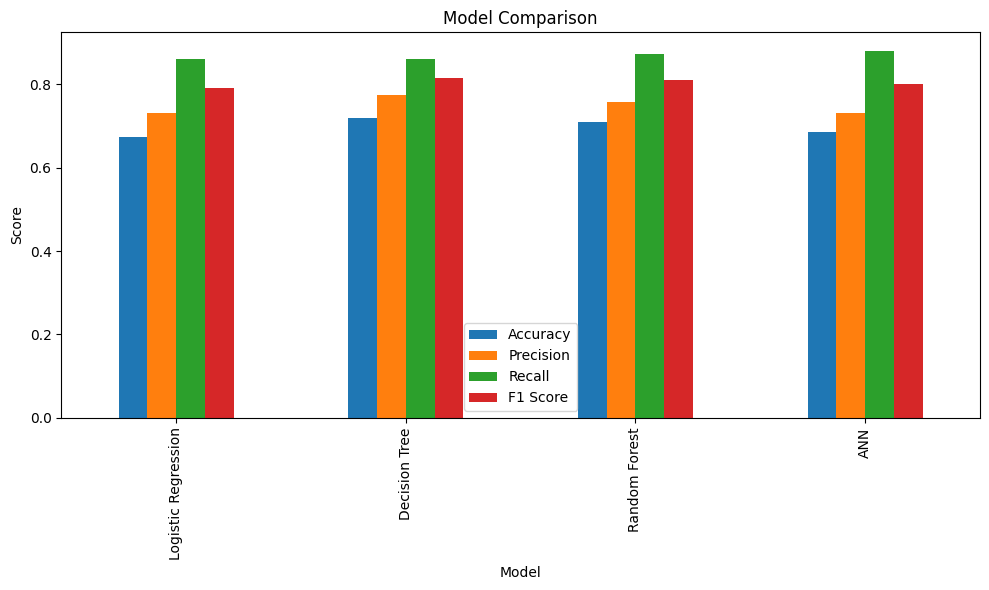

In [25]:
results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

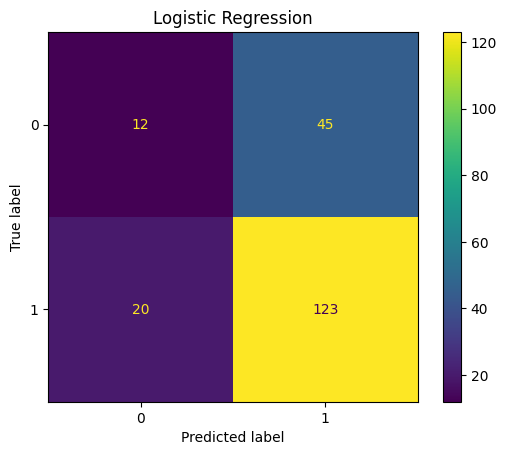

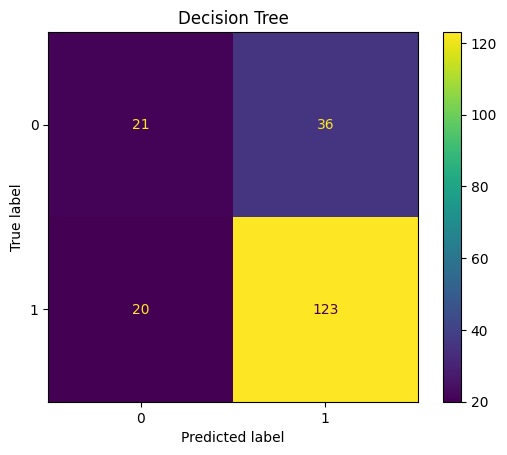

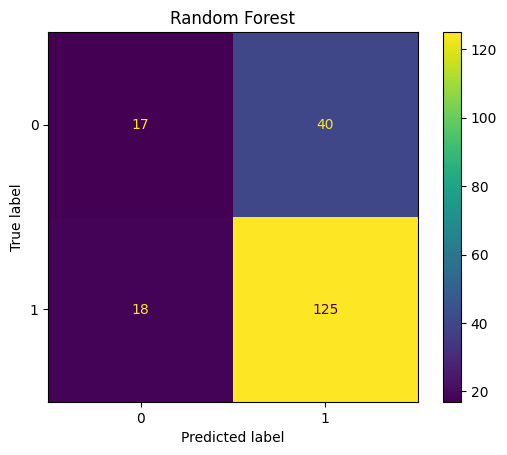

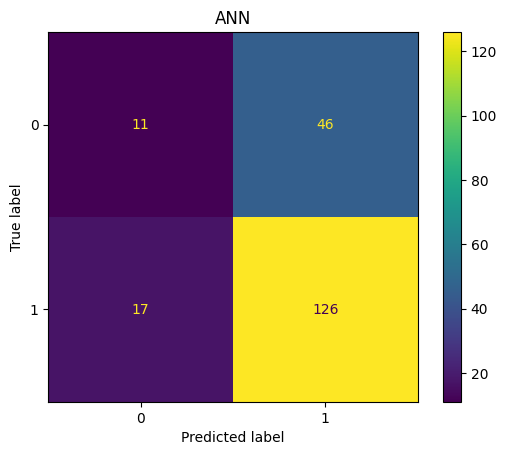

In [26]:
models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "ANN": ann_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(name)
    plt.show()

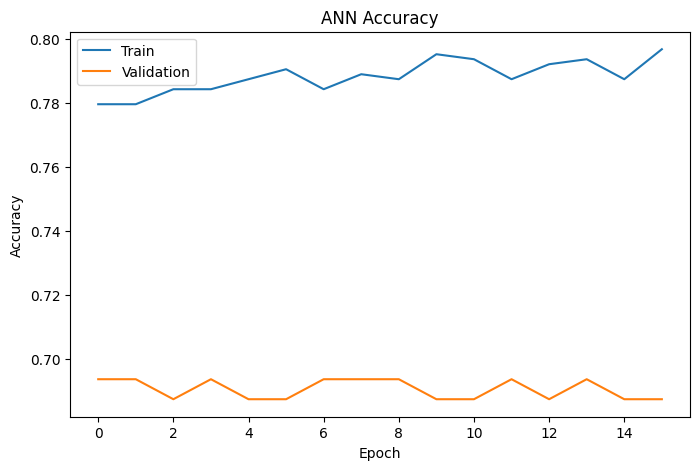

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

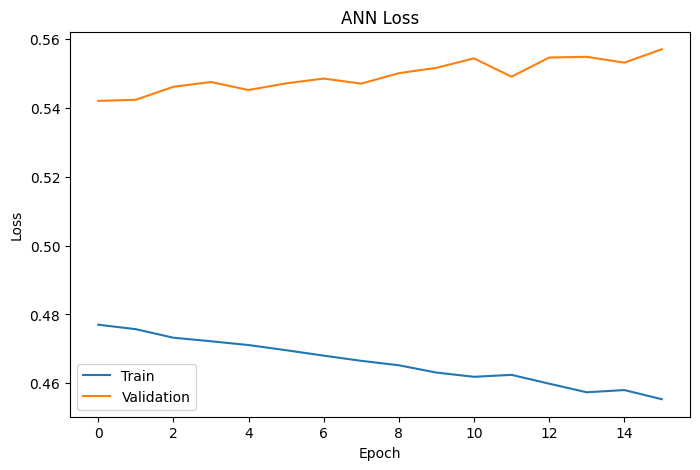

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [29]:
for model_name, prediction in models.items():

    print("\n", model_name)

    print("Accuracy :", accuracy_score(y_test, prediction))
    print("Precision:", precision_score(y_test, prediction))
    print("Recall   :", recall_score(y_test, prediction))
    print("F1 Score :", f1_score(y_test, prediction))


 Logistic Regression
Accuracy : 0.675
Precision: 0.7321428571428571
Recall   : 0.8601398601398601
F1 Score : 0.7909967845659164

 Decision Tree
Accuracy : 0.72
Precision: 0.7735849056603774
Recall   : 0.8601398601398601
F1 Score : 0.8145695364238411

 Random Forest
Accuracy : 0.71
Precision: 0.7575757575757576
Recall   : 0.8741258741258742
F1 Score : 0.8116883116883117

 ANN
Accuracy : 0.685
Precision: 0.7325581395348837
Recall   : 0.8811188811188811
F1 Score : 0.8
